In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd
import seaborn as sns
import os
from graph_tool.all import *
import scipy as sp
import sklearn
from tqdm import tqdm

import imageio
import os
import shutil

In [2]:
def read_file(fname, thr_len=0):
    data = []
    with open(fname) as f:
        for x in f:
            line = np.array([float(n) for n in x.split(", ")])
            if len(line)>thr_len:
                data.append(line)
    return data

In [3]:
def normalize(c,r,mu,mI,mO,mS,mHK,mu0,r0):
    mu_c = [np.array([(m-mu0*(1-t))/t for (m,t) in zip(mu[i],c[i])]) for i in range(len(c))]
    r_c = [np.array([(m-r0*(1-t))/t for (m,t) in zip(r[i],c[i])]) for i in range(len(c))]
    mI_c = [np.array([(m*(1-t))/t for (m,t) in zip(mI[i],c[i])]) for i in range(len(c))]
    mO_c = [np.array([(m*(1-t))/t for (m,t) in zip(mO[i],c[i])]) for i in range(len(c))]
    mS_c = [np.array([(m*(1-t))/t for (m,t) in zip(mS[i],c[i])]) for i in range(len(c))]
    mHK_c = [np.array([(m*(1-t))/t for (m,t) in zip(mHK[i],c[i])]) for i in range(len(c))]
    return r_c,mu_c,mI_c,mO_c,mS_c,mHK_c

In [31]:
I_mut = read_file("../Data/CancerEvo/single/mut_I.txt")
O_mut = read_file("../Data/CancerEvo/single/mut_O.txt")
S_mut = read_file("../Data/CancerEvo/single/mut_S.txt")
HK_mut = read_file("../Data/CancerEvo/single/mut_HK.txt")
ts = read_file("../Data/CancerEvo/single/tumors.txt")
I_mat = read_file("../Data/CancerEvo/single/I_mat.txt")
O_mat = read_file("../Data/CancerEvo/single/O_mat.txt")
S_mat = read_file("../Data/CancerEvo/single/S_mat.txt")
HK_mat = read_file("../Data/CancerEvo/single/HK_mat.txt")

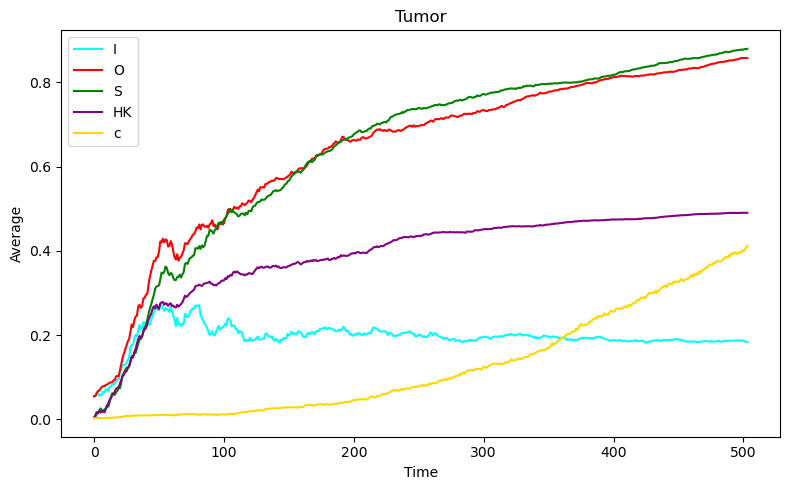

In [36]:
plt.figure(figsize=(8,5))
plt.plot(I_mut, color='cyan', label='I')
plt.plot(O_mut, color='red', label='O')
plt.plot(S_mut, color='green', label='S')
plt.plot(HK_mut, color='purple', label='HK')
plt.plot(ts, color='gold', label='c')

plt.title("Tumor")
plt.xlabel('Time')
plt.ylabel('Average')
plt.legend()
plt.tight_layout()

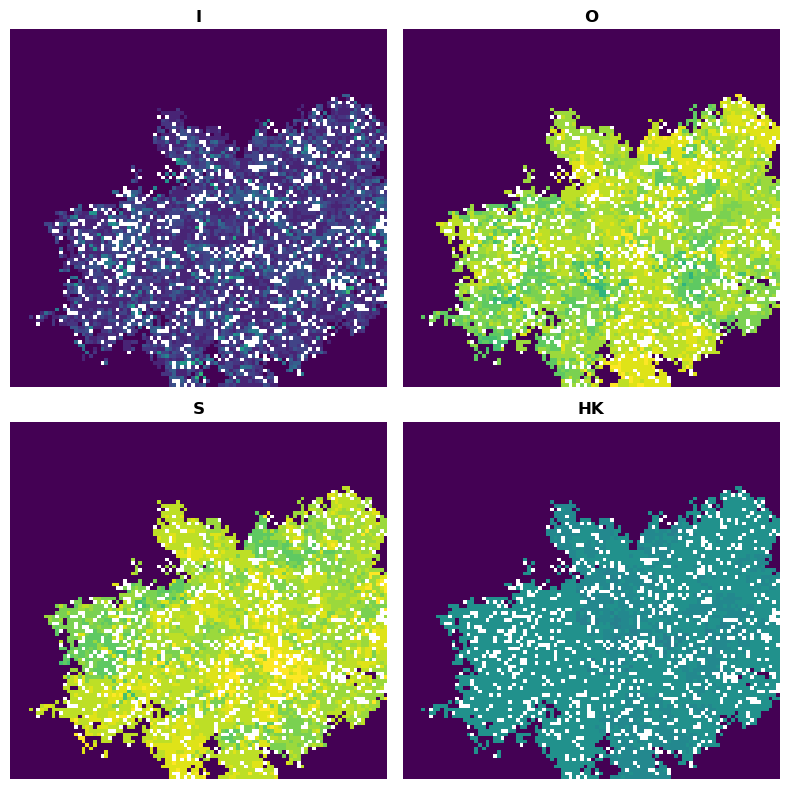

In [29]:
_,ax=plt.subplots(2,2,figsize=(8,8))
ax = ax.flatten()
sns.heatmap(I_mat, cmap="viridis", ax=ax[0], cbar=False, vmin=0, vmax=1)
sns.heatmap(O_mat, cmap="viridis", ax=ax[1], cbar=False, vmin=0, vmax=1)
sns.heatmap(S_mat, cmap="viridis", ax=ax[2], cbar=False, vmin=0, vmax=1)
sns.heatmap(HK_mat, cmap="viridis", ax=ax[3], cbar=False, vmin=0, vmax=1)
[axi.set_xticks([]) for axi in ax]
[axi.set_yticks([]) for axi in ax]
[axi.set_title(tit, fontweight="bold") for axi,tit in zip(ax,["I","O","S","HK"])]
plt.tight_layout()

In [126]:
idx = 17
c0 = read_file("../Data/CancerEvo/"+str(idx)+"_c.txt")
r = read_file("../Data/CancerEvo/"+str(idx)+"_r.txt")
mu = read_file("../Data/CancerEvo/"+str(idx)+"_mu.txt")
mI = read_file("../Data/CancerEvo/"+str(idx)+"_I.txt")
mO = read_file("../Data/CancerEvo/"+str(idx)+"_O.txt")
mS = read_file("../Data/CancerEvo/"+str(idx)+"_S.txt")
mHK = read_file("../Data/CancerEvo/"+str(idx)+"_HK.txt")
states = []
for c in c0:
    if c[-1]>0.49:
        states.append("Tumor")
    else:
        states.append("Health")
states = np.array(states)
#np.loadtxt("../Data/CancerEvo/"+str(idx)+"_state.txt", dtype=str)
#r_c0,mu_c0,mI_c0,mO_c0,mS_c0,mHK_c0 = normalize(c0,r,mu,mI,mO,mS,mHK,mu0,r0)

In [127]:
for c in c0:
    np.nan_to_num(c,0)

In [128]:
map_h = np.where(states=="Health")[0]
map_t = np.where(states=="Tumor")[0]
map_d = np.where(states=="Done")[0]

In [130]:
print(f"Probability health: {len(map_h)/len(states)}")
print(f"Probability tumor: {len(map_t)/len(states)}")
print(f"Probability done: {len(map_d)/len(states)}")

Probability health: 0.62
Probability tumor: 0.38
Probability done: 0.0


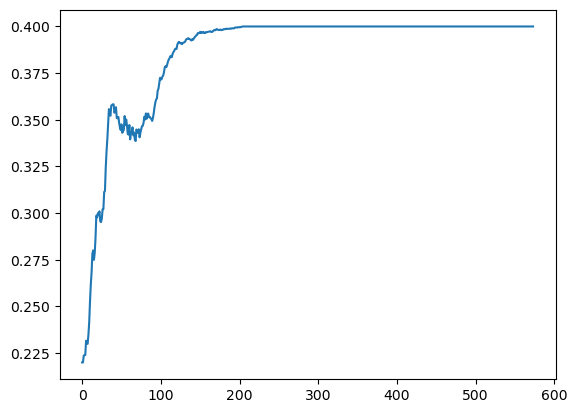

In [46]:
plt.plot(r[0])

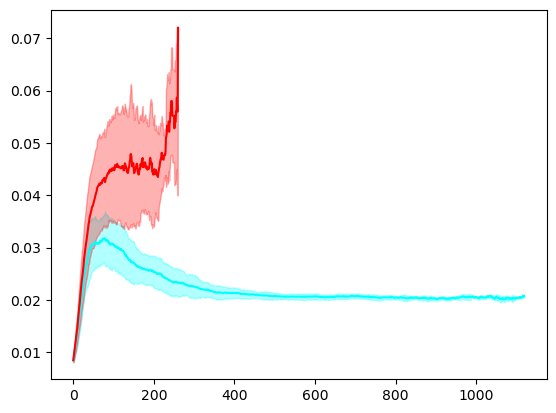

In [131]:
y, yerr  = stats_elementwise([mu[i] for i in map_t])
ci_half_width = yerr
x = np.arange(len(y))
plt.plot(x, y, color='cyan', label='I')
plt.fill_between(x,y-ci_half_width,y + ci_half_width,alpha=0.3,color='cyan')

y, yerr  = stats_elementwise([mu[i] for i in map_h])
ci_half_width = yerr
x = np.arange(len(y))
plt.plot(x, y, color='red', label='I')
plt.fill_between(x,y-ci_half_width,y + ci_half_width,alpha=0.3,color='red')

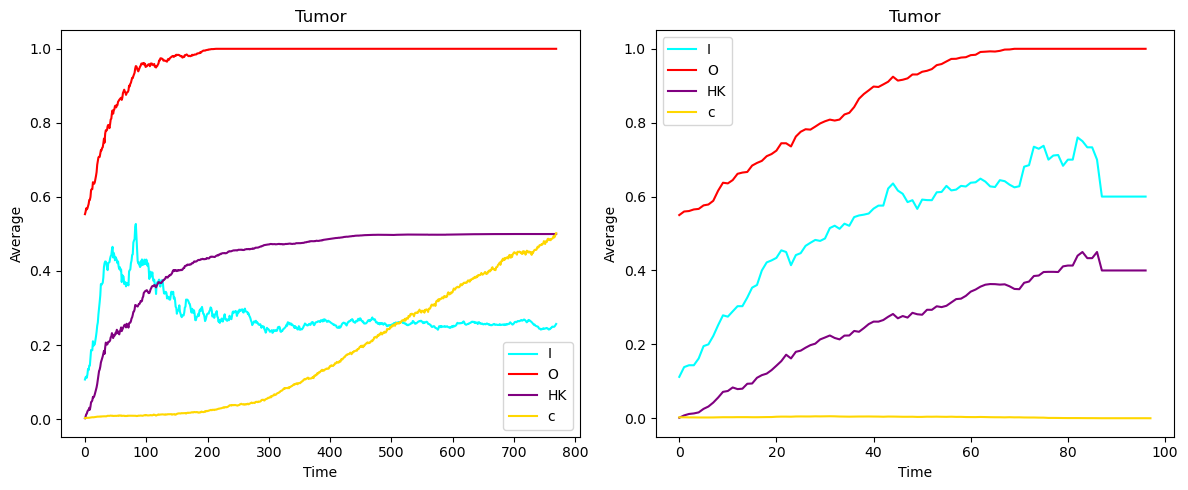

In [132]:
### Ratio I/O average gene mutation ###
plt.subplots(1,2,figsize=(12,5))

plt.subplot(1,2,1)

t_idx = map_t[1]

plt.plot(mu[t_idx]/8e-2, color='cyan', label='I')
plt.plot(r[t_idx]/0.4, color='red', label='O')
#plt.plot(mS[t_idx], color='green', label='S')
plt.plot(mHK[t_idx], color='purple', label='HK')
plt.plot(c0[t_idx], color='gold', label='c')

plt.title("Tumor")
plt.xlabel('Time')
plt.ylabel('Average')
plt.legend()

###################################################################################

plt.subplot(1,2,2)

h_idx = map_h[3]

plt.plot(mu[h_idx]/8e-2, color='cyan', label='I')
plt.plot(r[h_idx]/0.4, color='red', label='O')
#plt.plot(mS[h_idx], color='green', label='S')
plt.plot(mHK[h_idx], color='purple', label='HK')
plt.plot(c0[h_idx], color='gold', label='c')

plt.title("Tumor")
plt.xlabel('Time')
plt.ylabel('Average')
plt.legend()

plt.tight_layout()
plt.show()


In [11]:
def stats_elementwise(vs):
    """
    Compute element-wise mean and standard deviation across uneven-length sequences,
    ignoring out-of-range indices and NaNs.

    Parameters
    ----------
    vs : list of array-like
        A list of sequences (lists or numpy arrays) of possibly different lengths.

    Returns
    -------
    means : numpy.ndarray
        Array of length max(len(v) for v in vs) containing the mean at each position.
    stds : numpy.ndarray
        Array of same length containing the standard deviation at each position.
    """
    # Determine the maximum length
    n = max(len(v) for v in vs)
    
    # Preallocate results
    means = np.empty(n, dtype=float)
    stds = np.empty(n, dtype=float)
    
    for i in range(n):
        # Collect valid values at position i
        vals = [v[i] for v in vs if i < len(v) and not np.isnan(v[i])]
        
        if vals:
            arr = np.array(vals, dtype=float)
            means[i] = arr.mean()
            stds[i] = arr.std(ddof=0)  # population std; use ddof=1 for sample std
        else:
            means[i] = np.nan
            stds[i] = np.nan
            
    return means, stds

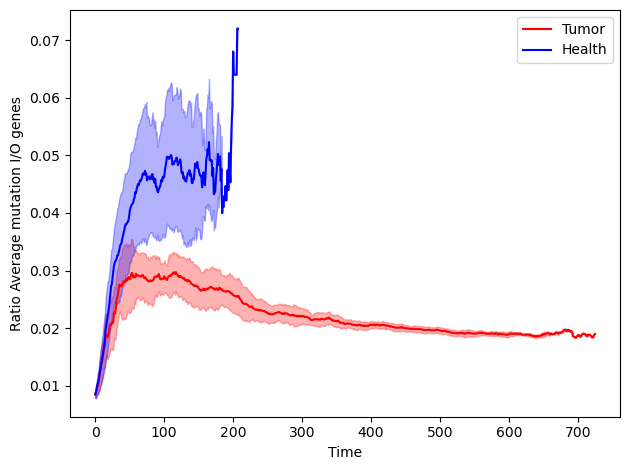

In [56]:
### Ratio I/O average gene mutation ###
plt.figure()

y, yerr  = stats_elementwise([mu[i] for i in map_t])
ci_half_width = yerr
x = np.arange(len(y))
plt.plot(x, y, color='red', label='Tumor')
plt.fill_between(x,y-ci_half_width,y + ci_half_width,alpha=0.3,color='red')

y, yerr  = stats_elementwise([mu[i] for i in map_h])
ci_half_width = yerr
x = np.arange(len(y))
plt.plot(x, y, color='blue', label='Health')
plt.fill_between(x,y-ci_half_width,y + ci_half_width,alpha=0.3,color='blue')

#y, yerr  = stats_elementwise([mI[i] for i in map_d])
#ci_half_width = yerr
#x = np.arange(len(y))
#plt.plot(x, y, color='gold', label='Done')
#plt.fill_between(x,y-ci_half_width,y + ci_half_width,alpha=0.3,color='gold')

plt.xlabel('Time')
plt.ylabel('Ratio Average mutation I/O genes')
plt.legend()
plt.tight_layout()
plt.show()


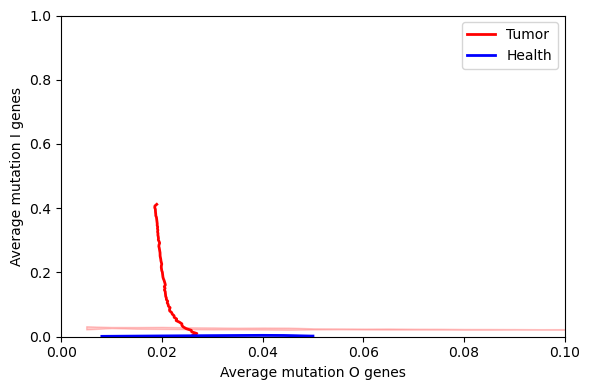

In [116]:
### O vs I progression ###

plt.figure(figsize=(6, 4))

# Tumor
x_common = np.linspace(0, 1, 200)
series = [[c0[i],mu[i]] for i in map_t]
df = pd.DataFrame({f"s{i}": np.interp(x_common, x, y, left=np.nan, right=np.nan) for i, (x, y) in enumerate(series)})
mean = df.mean(axis=1).to_numpy()
std  = df.std(axis=1).to_numpy()
plt.plot(mean, x_common, color="red", lw=2, label="Tumor")
plt.fill_between(x_common, mean - std, mean + std, color="red", alpha=0.2)

# Health
x_common = np.linspace(0, 0.05, 200)
series = [[mu[i],c0[i]] for i in map_h]
df = pd.DataFrame({f"s{i}": np.interp(x_common, x, y, left=np.nan, right=np.nan) for i, (x, y) in enumerate(series)})
mean = df.mean(axis=1).to_numpy()
std  = df.std(axis=1).to_numpy()
plt.plot(x_common, mean, color="blue", lw=2, label="Health")
plt.fill_between(x_common, mean - std, mean + std, color="blue", alpha=0.2)

# Done
#series = [[mO[i],mI[i]] for i in map_d]
#df = pd.DataFrame({f"s{i}": np.interp(x_common, x, y, left=np.nan, right=np.nan) for i, (x, y) in enumerate(series)})
#mean = df.mean(axis=1).to_numpy()
#std  = df.std(axis=1).to_numpy()
#plt.plot(x_common, mean, color="gold", lw=2, label="Done")
#plt.fill_between(x_common, mean - std, mean + std, color="gold", alpha=0.2)


plt.xlabel("Average mutation O genes")
plt.ylabel("Average mutation I genes")
plt.xlim([0,0.1])
plt.ylim([0,1])
plt.legend()
plt.tight_layout()
plt.show()


In [110]:
r_tum = np.concat([r[i] for i in map_t])
mu_tum = np.concat([mu[i] for i in map_t])

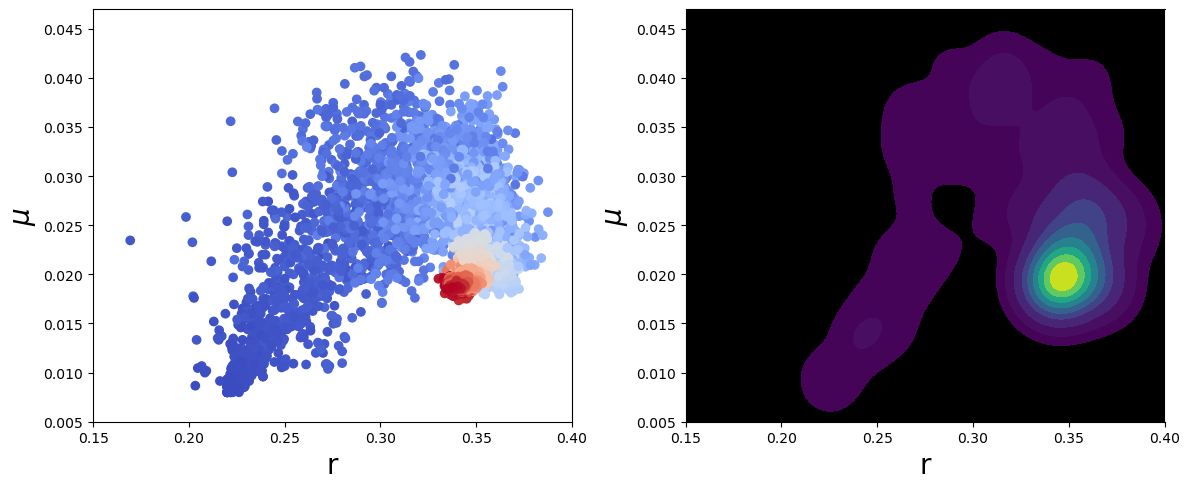

In [119]:
#### mu vs r progression in time ###
_,ax = plt.subplots(1,2,figsize=(12,5))

sns.kdeplot(x=r[i], y=mu[i], fill=True, thresh=0.02, cmap="viridis", ax=ax[1])
ax[1].set_facecolor("k")
ax[1].set_xlim([0.15,0.4])
ax[1].set_xlabel("r", fontsize=20)
ax[1].set_ylim([0.005, 0.047])
ax[1].set_ylabel(r"$\mu$", fontsize=20)
plt.tight_layout()

for i in map_t:
    ax[0].scatter(r[i], mu[i], c=cm.coolwarm(np.linspace(0,1,len(r[i]))), alpha=1)

ax[0].set_xlim([0.15,0.4])
ax[0].set_xlabel("r", fontsize=20)
ax[0].set_ylim([0.005, 0.047])
ax[0].set_ylabel(r"$\mu$", fontsize=20)
plt.tight_layout()

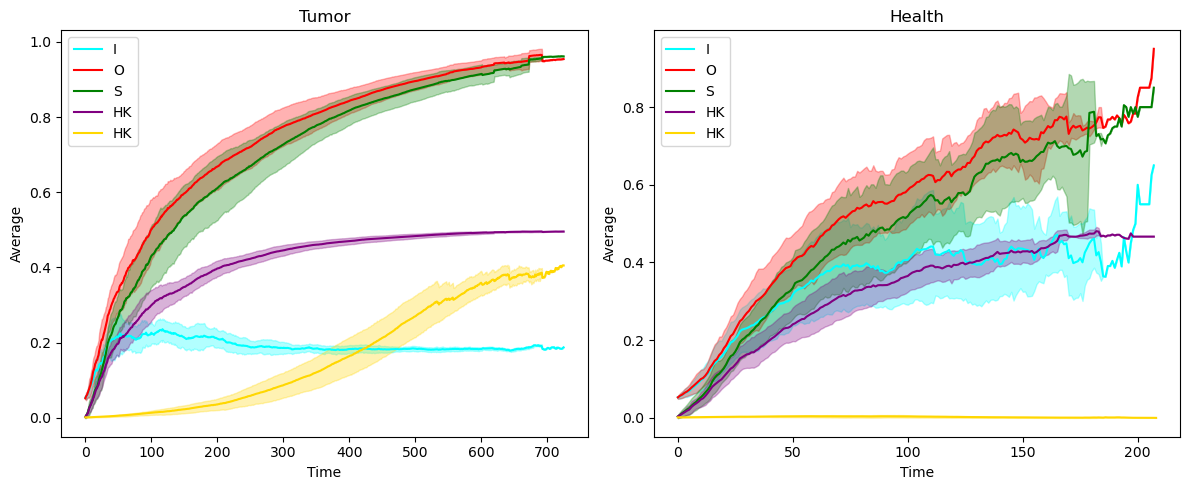

In [59]:
### Ratio I/O average gene mutation ###
plt.subplots(1,2,figsize=(12,5))

plt.subplot(1,2,1)

y, yerr  = stats_elementwise([mI[i] for i in map_t])
ci_half_width = yerr
x = np.arange(len(y))
plt.plot(x, y, color='cyan', label='I')
plt.fill_between(x,y-ci_half_width,y + ci_half_width,alpha=0.3,color='cyan')

y, yerr  = stats_elementwise([mO[i] for i in map_t])
ci_half_width = yerr
x = np.arange(len(y))
plt.plot(x, y, color='red', label='O')
plt.fill_between(x,y-ci_half_width,y + ci_half_width,alpha=0.3,color='red')

y, yerr  = stats_elementwise([mS[i] for i in map_t])
ci_half_width = yerr
x = np.arange(len(y))
plt.plot(x, y, color='green', label='S')
plt.fill_between(x,y-ci_half_width,y + ci_half_width,alpha=0.3,color='green')

y, yerr  = stats_elementwise([mHK[i] for i in map_t])
ci_half_width = yerr
x = np.arange(len(y))
plt.plot(x, y, color='purple', label='HK')
plt.fill_between(x,y-ci_half_width,y + ci_half_width,alpha=0.3,color='purple')

y, yerr  = stats_elementwise([c0[i] for i in map_t])
ci_half_width = yerr
x = np.arange(len(y))
plt.plot(x, y, color='gold', label='HK')
plt.fill_between(x,y-ci_half_width,y + ci_half_width,alpha=0.3,color='gold')

plt.title("Tumor")
plt.xlabel('Time')
plt.ylabel('Average')
plt.legend()

###################################################################################

plt.subplot(1,2,2)

y, yerr  = stats_elementwise([mI[i] for i in map_h])
ci_half_width = yerr
x = np.arange(len(y))
plt.plot(x, y, color='cyan', label='I')
plt.fill_between(x,y-ci_half_width,y + ci_half_width,alpha=0.3,color='cyan')

y, yerr  = stats_elementwise([mO[i] for i in map_h])
ci_half_width = yerr
x = np.arange(len(y))
plt.plot(x, y, color='red', label='O')
plt.fill_between(x,y-ci_half_width,y + ci_half_width,alpha=0.3,color='red')

y, yerr  = stats_elementwise([mS[i] for i in map_h])
ci_half_width = yerr
x = np.arange(len(y))
plt.plot(x, y, color='green', label='S')
plt.fill_between(x,y-ci_half_width,y + ci_half_width,alpha=0.3,color='green')

y, yerr  = stats_elementwise([mHK[i] for i in map_h])
ci_half_width = yerr
x = np.arange(len(y))
plt.plot(x, y, color='purple', label='HK')
plt.fill_between(x,y-ci_half_width,y + ci_half_width,alpha=0.3,color='purple')

y, yerr  = stats_elementwise([c0[i] for i in map_h])
ci_half_width = yerr
x = np.arange(len(y))
plt.plot(x, y, color='gold', label='HK')
plt.fill_between(x,y-ci_half_width,y + ci_half_width,alpha=0.3,color='gold')

plt.title("Health")
plt.xlabel('Time')
plt.ylabel('Average')
plt.legend()
plt.tight_layout()
plt.show()


# Analytics

In [111]:
def dyn_state(r,r0,mu,k,N):
    return r/r0, (1-(1-mu)**(2*k*N)*(1-mu**2)**(N*(1-2*k)))

In [400]:
r_prop_list = [1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0]
results = [-0.6101874390439277, 0.6226682669930774, 1.2917773010287472, 1.8387745389776091, 2.2434712898547584, 2.660774128739252, 2.9356429157955044, 3.1821620335205547, 3.4130647650803505, 3.625270864316522, 3.8084414875435573]
results = np.array(results)
p_die_data = [(1-(1-m*1e-2)**(10)) for m in results]

Text(0, 0.5, '$\\mu$')

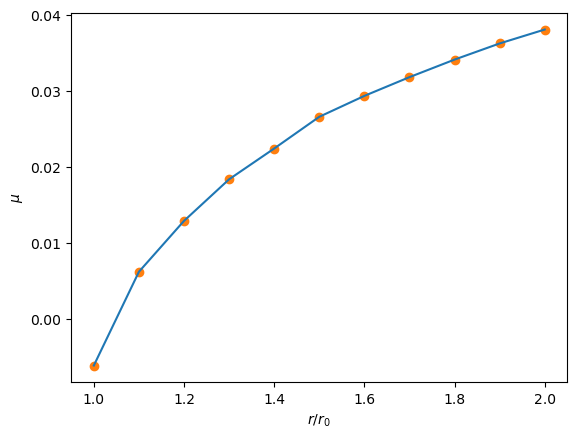

In [269]:
plt.plot(r_prop_list, results*1e-2)
plt.scatter(r_prop_list, results*1e-2, c="C1")
plt.xlabel(r"$r/r_0$")
plt.ylabel(r"$\mu$")

In [176]:
from scipy.interpolate import make_smoothing_spline

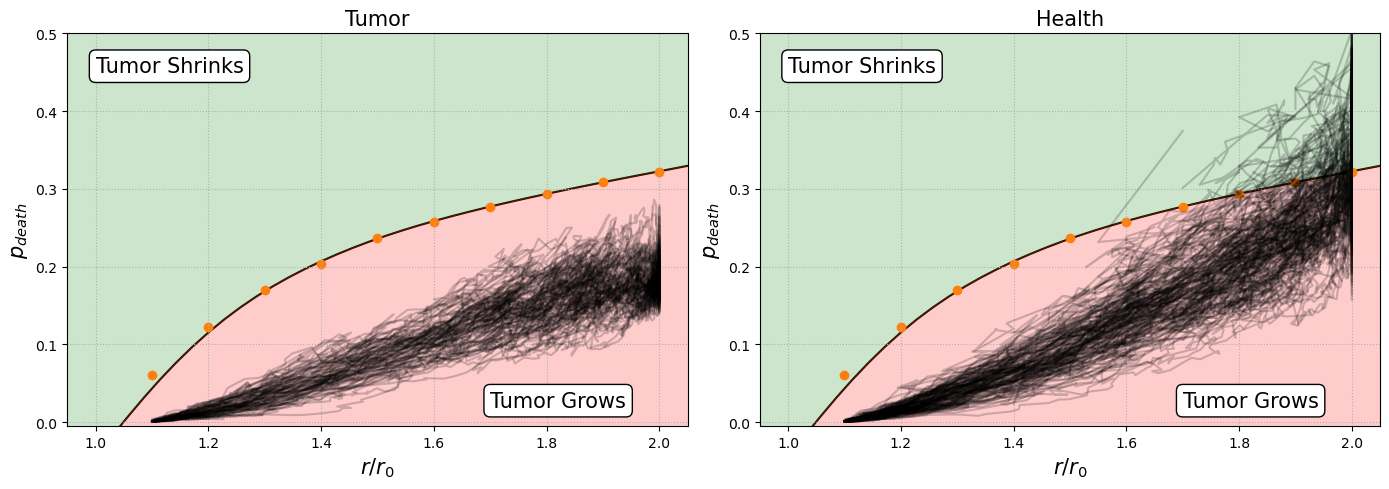

In [345]:
r0=2e-1
N=10
_,ax = plt.subplots(1,2,figsize=(14,5))
spl = make_smoothing_spline(r_prop_list, p_die, lam=0.001)
x_new = np.linspace(0.8,2.2,50)
ax[0].plot(x_new, spl(x_new), color="k", zorder=0)
ax[0].fill_between(x_new, spl(x_new),max(spl(x_new))*1.5, alpha=0.2, color="green")
ax[0].fill_between(x_new, -1, spl(x_new), alpha=0.2, color="red")
ax[0].scatter(r_prop_list, p_die, color="C1")
ax[1].plot(x_new, spl(x_new), color="k", zorder=0)
ax[1].fill_between(x_new, spl(x_new),max(spl(x_new))*1.5, alpha=0.2, color="green")
ax[1].fill_between(x_new, -1, spl(x_new), alpha=0.2, color="red")
ax[1].scatter(r_prop_list, p_die, color="C1")

#points = np.array([dyn_state(r=r, r0=r0, mu=mu, k=k, N=N) for r,mu,k in zip(r[map_t[7]],mu[map_t[7]],mHK[map_t[7]])])
#imt = plt.scatter(*points.T, c=np.linspace(0,1,len(points)), cmap="coolwarm", label="Tumor")
for i in range(len(map_h)):
    points = np.array([dyn_state(r=r, r0=r0, mu=mu, k=k, N=N) for r,mu,k in zip(r[map_h[i]],mu[map_h[i]],mHK[map_h[i]])])
    imh = ax[1].plot(*points.T, c="k", alpha=0.2)#, label="Health")

for i in range(len(map_t)):
    points = np.array([dyn_state(r=r, r0=r0, mu=mu, k=k, N=N) for r,mu,k in zip(r[map_t[i]],mu[map_t[i]],mHK[map_t[i]])])
    imt = ax[0].plot(*points.T, c="k", alpha=0.2)#, label="Health")

[axi.set_xlabel(r"$r/r_0$", fontsize=15) for axi in ax]
[axi.set_ylabel(r"$p_{death}$", fontsize=15) for axi in ax]
[axi.set_xlim([0.95,2.05]) for axi in ax]
[axi.set_ylim([-0.005,0.5]) for axi in ax]
#plt.legend()
[axi.grid(ls=":") for axi in ax]
ax[0].set_title("Tumor", fontsize=15)
ax[1].set_title("Health", fontsize=15)
#plt.colorbar(imh, label="Progression")
#plt.colorbar(imt)
[axi.text(1,0.45,"Tumor Shrinks", bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'), fontsize=15) for axi in ax]
[axi.text(1.7,0.02,"Tumor Grows", bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'), fontsize=15) for axi in ax]
plt.tight_layout()
plt.savefig("../CancerEvo/images/diag.png")

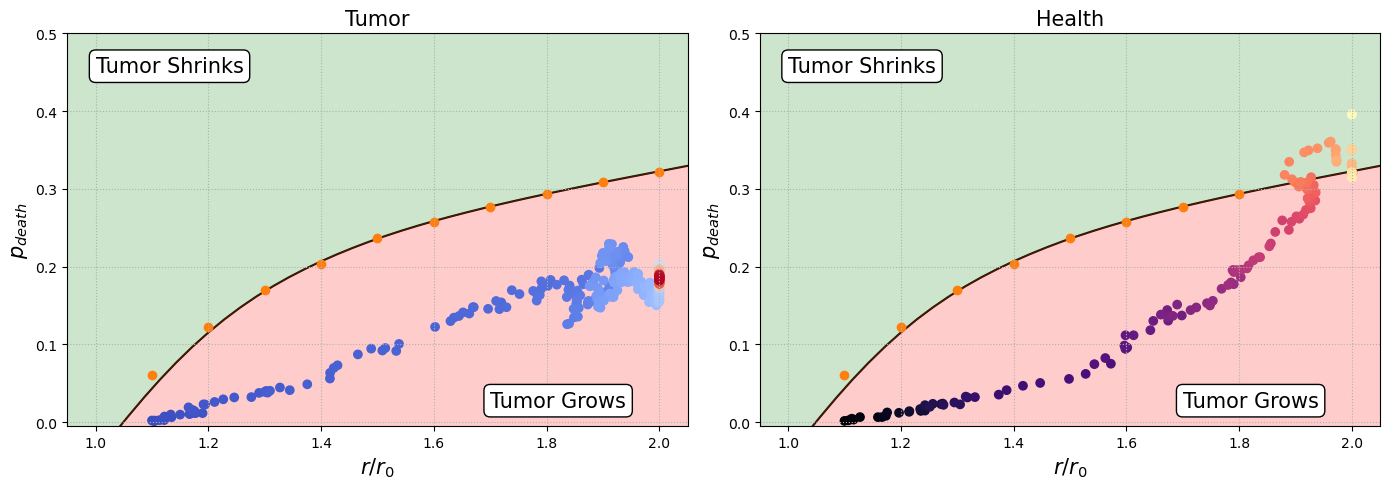

In [403]:
r0=2e-1
N=10
_,ax = plt.subplots(1,2,figsize=(14,5))
spl = make_smoothing_spline(r_prop_list, p_die_data, lam=0.001)
x_new = np.linspace(0.8,2.2,50)
ax[0].plot(x_new, spl(x_new), color="k", zorder=0)
ax[0].fill_between(x_new, spl(x_new),max(spl(x_new))*1.5, alpha=0.2, color="green")
ax[0].fill_between(x_new, -1, spl(x_new), alpha=0.2, color="red")
ax[0].scatter(r_prop_list, p_die_data, color="C1")
ax[1].plot(x_new, spl(x_new), color="k", zorder=0)
ax[1].fill_between(x_new, spl(x_new),max(spl(x_new))*1.5, alpha=0.2, color="green")
ax[1].fill_between(x_new, -1, spl(x_new), alpha=0.2, color="red")
ax[1].scatter(r_prop_list, p_die_data, color="C1")

points = np.array([dyn_state(r=r, r0=r0, mu=mu, k=k, N=N) for r,mu,k in zip(r[map_t[12]],mu[map_t[12]],mHK[map_t[12]])])
ax[0].scatter(*points.T, c=cm.coolwarm(np.linspace(0,1,len(points))), label="Tumor")
points = np.array([dyn_state(r=r, r0=r0, mu=mu, k=k, N=N) for r,mu,k in zip(r[map_h[7]],mu[map_h[7]],mHK[map_h[7]])])
ax[1].scatter(*points.T, c=cm.magma(np.linspace(0,1,len(points))), label="Health")

[axi.set_xlabel(r"$r/r_0$", fontsize=15) for axi in ax]
[axi.set_ylabel(r"$p_{death}$", fontsize=15) for axi in ax]
[axi.set_xlim([0.95,2.05]) for axi in ax]
[axi.set_ylim([-0.005,0.5]) for axi in ax]
#plt.legend()
[axi.grid(ls=":") for axi in ax]
ax[0].set_title("Tumor", fontsize=15)
ax[1].set_title("Health", fontsize=15)
#plt.colorbar(imh, label="Progression")
#plt.colorbar(imt)
[axi.text(1,0.45,"Tumor Shrinks", bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'), fontsize=15) for axi in ax]
[axi.text(1.7,0.02,"Tumor Grows", bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'), fontsize=15) for axi in ax]
plt.tight_layout()
#plt.savefig("../CancerEvo/images/diag_2traj_0.png")

In [ ]:
"""
rs_1 = np.loadtxt("../Data/CancerEvo/single/r_1.txt")
mus_1 = np.loadtxt("../Data/CancerEvo/single/m_1.txt")
k_1 = np.loadtxt("../Data/CancerEvo/single/k_1.txt")
t_1 = np.loadtxt("../Data/CancerEvo/single/t_1.txt")

rs_2 = np.loadtxt("../Data/CancerEvo/single/r_2.txt")
mus_2 = np.loadtxt("../Data/CancerEvo/single/m_2.txt")
k_2 = np.loadtxt("../Data/CancerEvo/single/k_2.txt")
t_2 = np.loadtxt("../Data/CancerEvo/single/t_2.txt")

rs_3 = np.loadtxt("../Data/CancerEvo/single/r_3.txt")
mus_3 = np.loadtxt("../Data/CancerEvo/single/m_3.txt")
k_3 = np.loadtxt("../Data/CancerEvo/single/k_3.txt")
t_3 = np.loadtxt("../Data/CancerEvo/single/t_3.txt")

rs = np.concatenate([rs,rs_1,rs_2,rs_3])
mus = np.concatenate([mus,mus_1,mus_2,mus_3])
k = np.concatenate([k,k_1,k_2,k_3])
t = np.concatenate([t,t_1,t_2,t_3])
"""

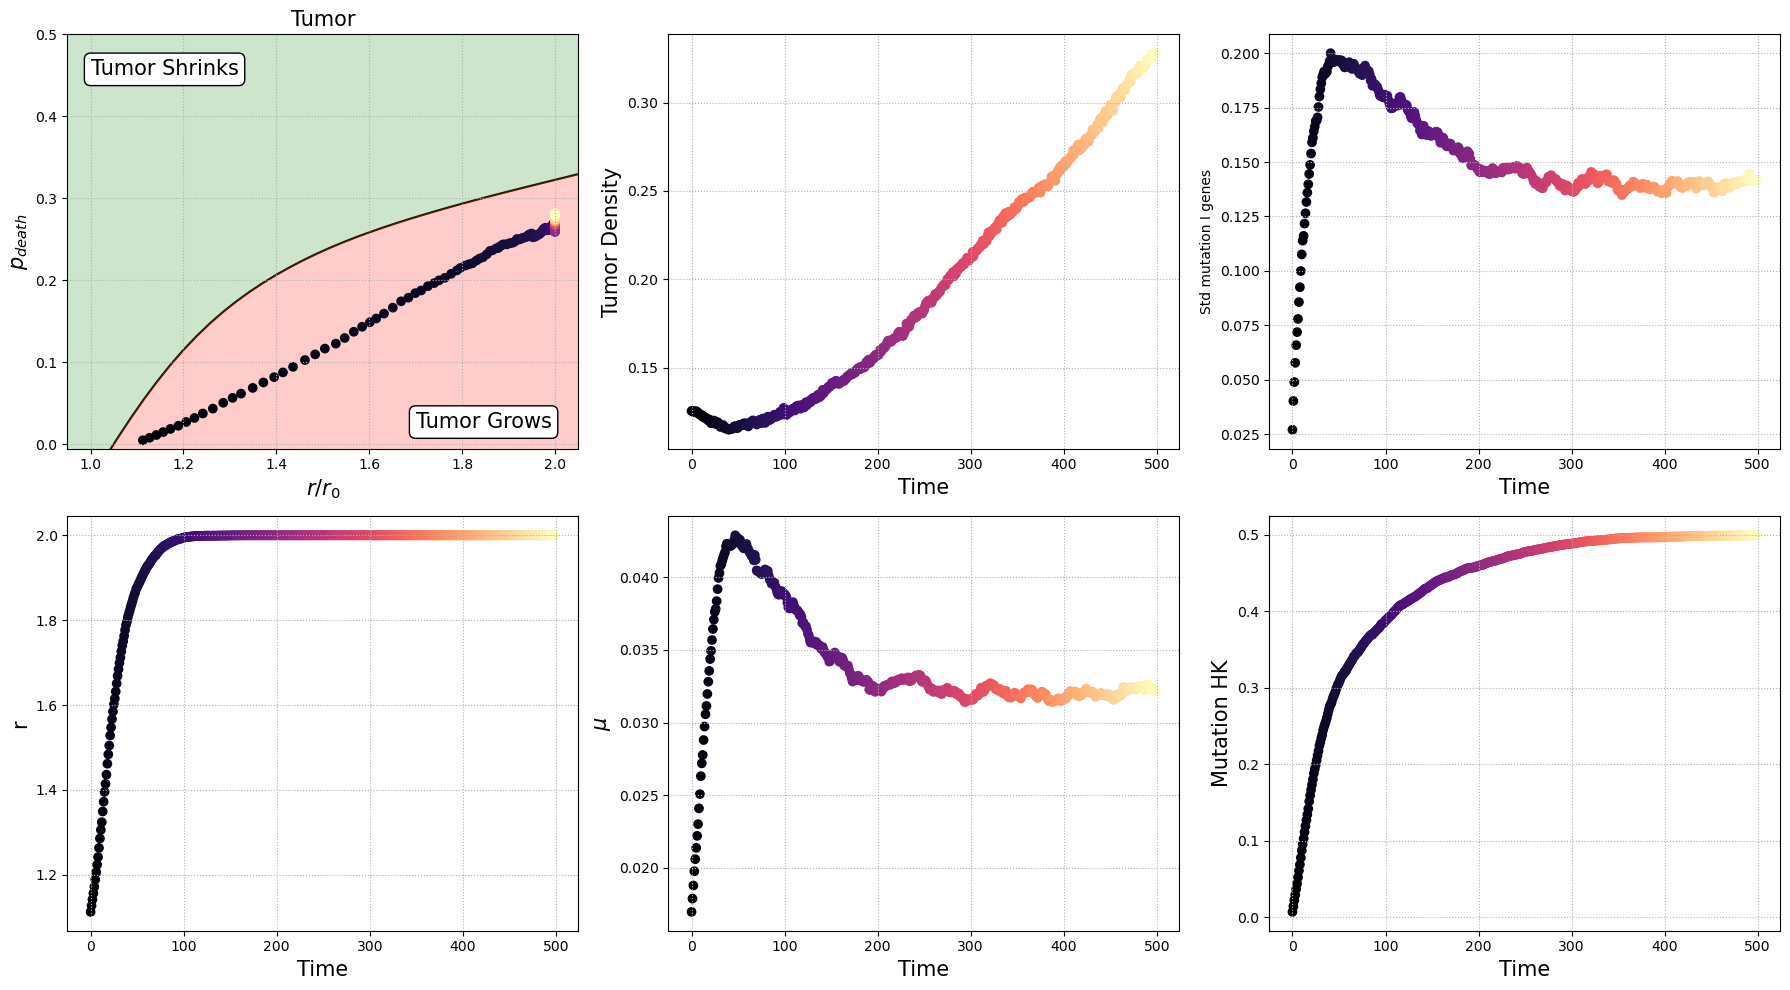

In [698]:
rs = np.loadtxt("../Data/CancerEvo/single/4_r_1.txt")
mus = np.loadtxt("../Data/CancerEvo/single/4_m_1.txt")
k = np.loadtxt("../Data/CancerEvo/single/4_k_1.txt")
t = np.loadtxt("../Data/CancerEvo/single/4_t_1.txt")
mstd = np.loadtxt("../Data/CancerEvo/single/4_mstd_1.txt")

p_die = [(1-(1-m)**(10)) for m in mus]
r0=2e-1
N=10
_,ax = plt.subplots(2,3,figsize=(18,10))
ax = ax.flatten()
spl = make_smoothing_spline(r_prop_list, p_die_data, lam=0.001)
x_new = np.linspace(0.8,2.2,50)
ax[0].plot(x_new, spl(x_new), color="k", zorder=0)
ax[0].fill_between(x_new, spl(x_new),max(spl(x_new))*1.5, alpha=0.2, color="green")
ax[0].fill_between(x_new, -1, spl(x_new), alpha=0.2, color="red")

points = np.array([dyn_state(r=r, r0=r0, mu=mu, k=k, N=N) for r,mu,k in zip(rs,mus,k)])
ax[0].scatter(*points.T, c=np.linspace(0,1,len(points)), cmap="magma", label="Tumor")

ax[1].scatter(np.arange(len(t)), t, c=np.arange(len(t)), cmap="magma", zorder=0)
#ax[2].scatter(np.arange(len(t)), [spl(rsi/r0)-p_d for rsi,p_d in zip(rs, points[:,1])], c=np.arange(len(t)), cmap="magma", zorder=0)
#ax[2].hlines(0,0,len(t), color="red", ls="--")
ax[2].scatter(np.arange(len(t)), mstd, c=np.arange(len(t)), cmap="magma", zorder=0)
ax[3].scatter(np.arange(len(t)), rs/r0, c=np.arange(len(t)), cmap="magma", zorder=0)
ax[4].scatter(np.arange(len(t)), mus, c=np.arange(len(t)), cmap="magma", zorder=0)
ax[5].scatter(np.arange(len(t)), k, c=np.arange(len(t)), cmap="magma", zorder=0)



ax[0].set_xlabel(r"$r/r_0$", fontsize=15)
ax[0].set_ylabel(r"$p_{death}$", fontsize=15)
ax[1].set_xlabel("Time", fontsize=15)
ax[1].set_ylabel("Tumor Density", fontsize=15)
ax[2].set_xlabel("Time", fontsize=15)
#ax[2].set_ylabel(r"$p_{die,exp}-p_{die,true}$", fontsize=15)
ax[2].set_ylabel("Std mutation I genes")
ax[3].set_xlabel("Time", fontsize=15)
ax[3].set_ylabel("r", fontsize=15)
ax[4].set_xlabel("Time", fontsize=15)
ax[4].set_ylabel(r"$\mu$", fontsize=15)
ax[5].set_xlabel("Time", fontsize=15)
ax[5].set_ylabel("Mutation HK", fontsize=15)

ax[0].set_xlim([0.95,2.05])
ax[0].set_ylim([-0.005,0.5])
#plt.legend()
[axi.grid(ls=":") for axi in ax]
ax[0].set_title("Tumor", fontsize=15)
#plt.colorbar(imh, label="Progression")
#plt.colorbar(imt)
ax[0].text(1,0.45,"Tumor Shrinks", bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'), fontsize=15)
ax[0].text(1.7,0.02,"Tumor Grows", bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'), fontsize=15)
plt.tight_layout()
#plt.savefig("../CancerEvo/images/diag_2traj_nofluct_2_1.png")

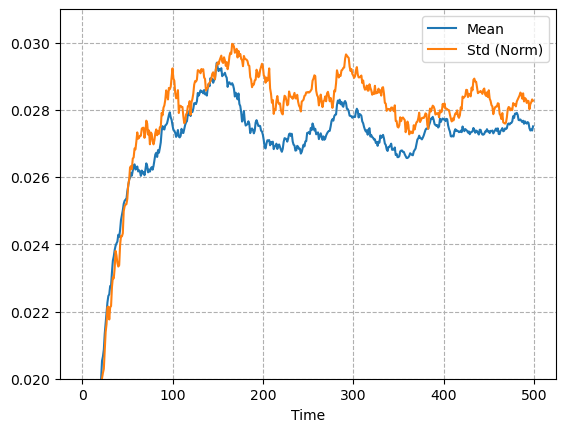

In [693]:
plt.plot(np.arange(500), mus, label="Mean")
plt.plot(mstd/5, label="Std (Norm)")
plt.legend()
plt.ylim([0.02,0.031])
plt.grid(ls="--")
plt.xlabel("Time")
plt.show()

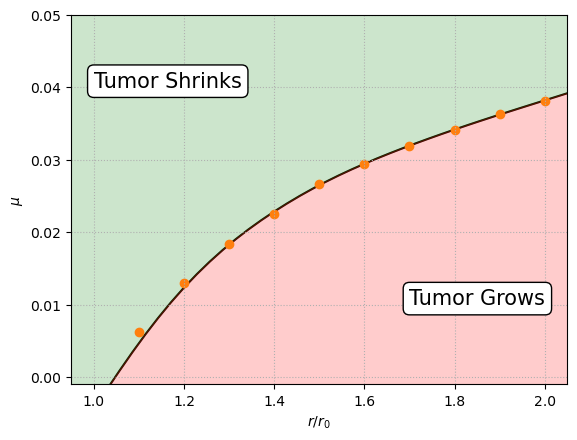

In [303]:
r0=2e-1
N=10

spl = make_smoothing_spline(r_prop_list, results*1e-2, lam=0.001)
x_new = np.linspace(0.8,2.2,50)
plt.plot(x_new, spl(x_new), color="k", zorder=0)
plt.fill_between(x_new, spl(x_new),max(spl(x_new))*1.5, alpha=0.2, color="green")
plt.fill_between(x_new, -1, spl(x_new), alpha=0.2, color="red")
plt.scatter(r_prop_list, results*1e-2, color="C1")

#points = np.array([dyn_state(r=r, r0=r0, mu=mu, k=k, N=N) for r,mu,k in zip(r[map_t[7]],mu[map_t[7]],mHK[map_t[7]])])
#plt.scatter(*points.T, c=cm.coolwarm(np.linspace(0,1,len(points))), label="Tumor")
#points = np.array([dyn_state(r=r, r0=r0, mu=mu, k=k, N=N) for r,mu,k in zip(r[map_h[7]],mu[map_h[7]],mHK[map_h[7]])])
#plt.scatter(*points.T, c=cm.magma(np.linspace(0,1,len(points))), label="Health")

plt.xlabel(r"$r/r_0$")
#plt.ylabel(r"$p_{death}$")
plt.ylabel(r"$\mu$")
plt.xlim([0.95,2.05])
plt.ylim([-0.001,0.05])
plt.text(1,0.04,"Tumor Shrinks", bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'), fontsize=15)
plt.text(1.7,0.01,"Tumor Grows", bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'), fontsize=15)

#plt.legend()
plt.grid(ls=":")

In [715]:
counts = np.loadtxt("../Data/CancerEvo/single/counts.txt", dtype=str, delimiter="?")
counts = np.array([np.array(ci).astype(float)*np.arange(1,6) for ci in[c.split(", ") for c in counts[300:-1]]])

<ErrorbarContainer object of 3 artists>

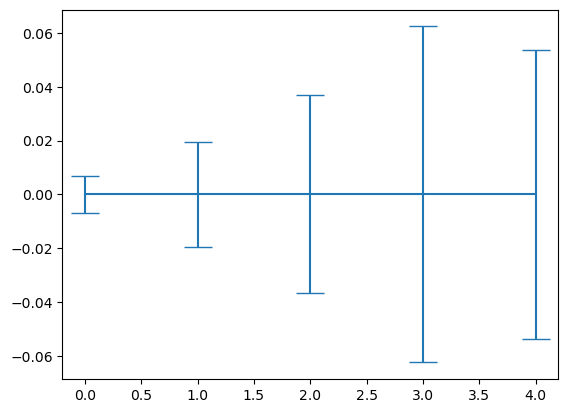

In [716]:
plt.errorbar(np.arange(5), np.mean(counts,axis=0)-np.mean(counts,axis=0), yerr=np.std(counts,axis=0), capsize=10)

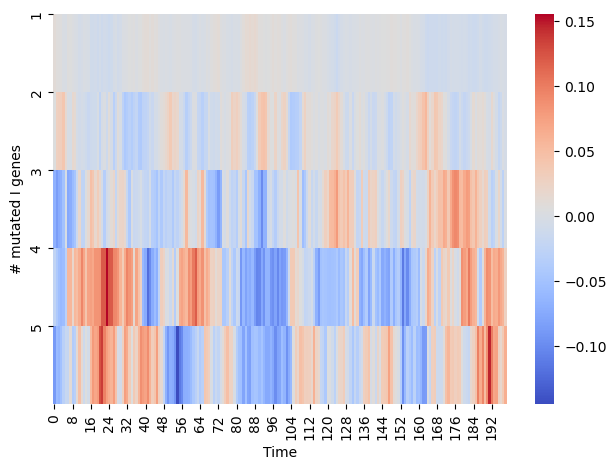

In [722]:
sns.heatmap((counts-np.mean(counts,axis=0)).T, cmap="coolwarm")
plt.xlabel("Time")
#plt.xticks(np.arange(0,100,10), labels=np.arange(0,100,10))
plt.ylabel("# mutated I genes")
plt.yticks(np.arange(0,5), labels=np.arange(1,6))
plt.tight_layout()
plt.savefig("images/haetmap_pop_1.png")

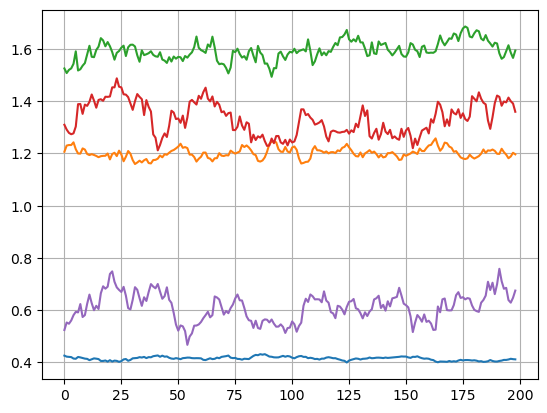

In [727]:
plt.plot(counts[:,:5])
plt.grid()
plt.show()

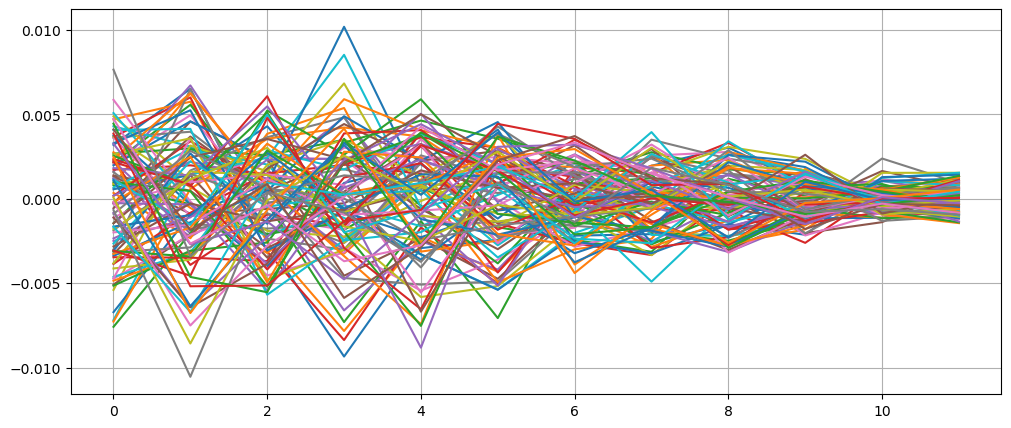

In [636]:
plt.figure(figsize=(12,5))
for i,c in enumerate(counts[:-1]):
    plt.plot(np.arange(12), (c-np.mean(counts,axis=0)), label=str(i))
#plt.legend()
#plt.ylim([2,3.1])
plt.grid()

# Old

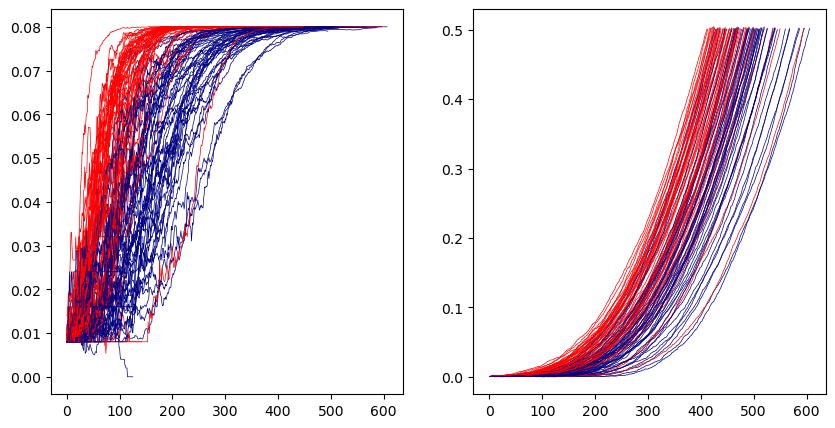

In [28]:
plt.subplots(1,2,figsize=(10,5))
plt.subplot(1,2,1)
for m0,m1 in zip(mu_c0, mu_c1):
    plt.plot(m0, color="red", lw=0.5)
    plt.plot(m1, color="navy", lw=0.5)

plt.subplot(1,2,2)
for m0,m1 in zip(c0, c1):
    plt.plot(m0, color="red", lw=0.5)
    plt.plot(m1, color="navy", lw=0.5)

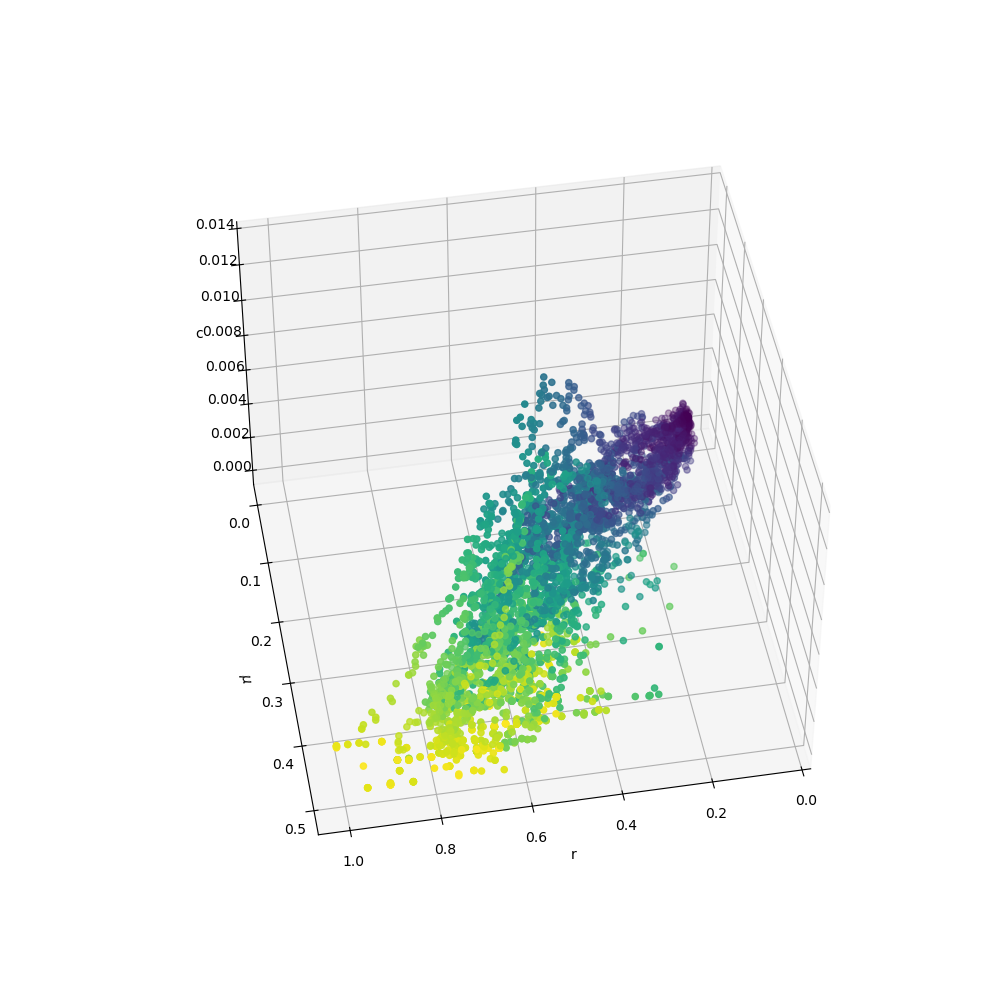

In [126]:
# 1) enable interactive notebook backend
%matplotlib widget

from matplotlib import cm
ax = plt.figure(figsize=(10,10)).add_subplot(projection='3d')

idx = 0
#for i in map_t:
#        ax.scatter(mO[i], mHK[i], c0[i], zdir='z', label='points in (x, z)', c = cm.coolwarm(np.linspace(0,1,len(c0[i]))))

for i in map_h:
        ax.scatter(mO[i], mHK[i], c0[i], zdir='z', label='points in (x, z)', c = cm.viridis(np.linspace(0,1,len(c0[i]))))
    
ax.set_xlabel('r')
ax.set_ylabel(r'$\mu$')
ax.set_zlabel('c')
ax.view_init(elev=45., azim=80, roll=0)

plt.show()

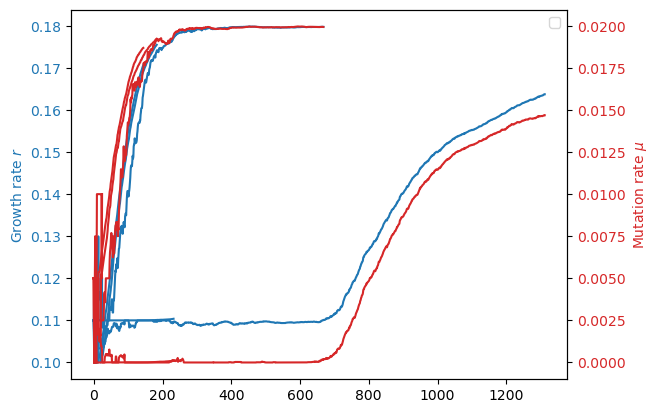

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# create a date index
dates = pd.date_range("2025-01-01", periods=100)

# make two series with very different ranges
ts1 = pd.Series(np.random.randn(100).cumsum(), index=dates)         # e.g. around ±10–20
ts2 = pd.Series(1000 + 5*np.random.randn(100).cumsum(), index=dates) # e.g. around 1000±50

# start your figure and first axis
fig, ax1 = plt.subplots()

# plot the first series on ax1
for i in range(20):
    if len(c[i]>100):
        ax1.plot(r_c[i], color="tab:blue")#, label=r"$r$")
ax1.set_ylabel(r"Growth rate $r$", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

# create a second y-axis that shares the x-axis with ax1
ax2 = ax1.twinx()
for i in range(20):
    if len(c[i]>100):
        ax2.plot(mu_c[i], color="tab:red")#, label=r"$\mu$")
ax2.set_ylabel(r"Mutation rate $\mu$", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")


# if you want a combined legend:
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

plt.show()


## Gif

In [487]:
filenames = [f"image{i}.png" for i in range(20)]
# Create a GIF
with imageio.get_writer('gif/tumor_stable.gif', mode='I', duration=0.5) as writer:
    for filename in filenames:
        image = imageio.v2.imread("../Data/CancerEvo/gif/"+filename)
        writer.append_data(image)

# Remove the image files for filename in filenames:
shutil.rmtree('../Data/CancerEvo/gif')